In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
def load_price_csv(data: pd.DataFrame) -> pd.DataFrame:

    price_col = 'Day-ahead Price (EUR/MWh)'
    data[["start_str", "end_str"]] = data["MTU (UTC)"].str.split(" - ", expand=True)
    data["start"] = pd.to_datetime(data["start_str"], format="%d/%m/%Y %H:%M:%S")
    data["end"]   = pd.to_datetime(data["end_str"],   format="%d/%m/%Y %H:%M:%S")
    data = data.rename(columns={price_col: 'price'})
    data = data[['start', 'price']].set_index('start')
    return data

price_df = load_price_csv(pd.read_csv('2025_DA_prices.csv'))
price_df

,price
start,
2025-01-01 00:00:00,2.19
2025-01-01 00:15:00,2.19
2025-01-01 00:30:00,2.19
2025-01-01 00:45:00,2.19
2025-01-01 01:00:00,2.18
...,...
2025-12-31 22:45:00,100.69
2025-12-31 23:00:00,109.53
2025-12-31 23:15:00,107.86


In [32]:
# measure daily price spread
daily = price_df.resample("D")["price"].agg(["min", "max", "mean", "std"])
daily["spread"] = daily["max"] - daily["min"]
daily.rename(columns={'std': 'volatility'}, inplace=True)

In [33]:
# see the diffs
price_df['diff'] = price_df['price'].diff()

daily["mean_abs_diff"] = price_df.resample("D")["diff"].apply(lambda x: x.abs().mean())
daily["mean_abs_diff"].sort_values(ascending=False)

start
2025-11-25    30.405417
2025-10-14    23.061562
2025-10-13    20.492604
2025-12-01    20.335937
2025-10-15    19.467500
                ...    
2025-01-25     1.465729
2025-07-27     1.453646
2025-07-12     1.407708
2025-01-11     1.270417
2025-01-19     1.247500
Name: mean_abs_diff, Length: 365, dtype: float64

In [ ]:
for col in ["spread", "mean_abs_diff", "volatility"]:
    daily[col + "_z"] = (
        (daily[col] - daily[col].mean()) /
        daily[col].std()
    )

daily['rank'] = daily['spread'] / (daily['mean_abs_diff'] + 1e-6)
rank = daily['rank'].sort_values(ascending=False)
easy = rank[:3].index.to_list()
hard = rank[-3:].index.to_list()

easy, hard

([Timestamp('2025-09-21 00:00:00'),
  Timestamp('2025-03-23 00:00:00'),
  Timestamp('2025-01-04 00:00:00')],
 [Timestamp('2025-10-10 00:00:00'),
  Timestamp('2025-12-11 00:00:00'),
  Timestamp('2025-10-12 00:00:00')])

In [43]:
import math


def plot_days(price_df, days):

    if not isinstance(price_df.index, pd.DatetimeIndex):
        raise ValueError("price_df must have a DatetimeIndex")

    n_days = len(days)
    n_cols = 3
    n_rows = math.ceil(n_days / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 3.5 * n_rows),
        sharey=True
    )

    # Always convert axes to flat numpy array
    axes = np.array(axes).reshape(-1)

    y_min = price_df["price"].min()
    y_max = price_df["price"].max()

    for i, day in enumerate(days):
        ax = axes[i]

        day = pd.Timestamp(day).normalize()
        mask = price_df.index.normalize() == day
        day_data = price_df.loc[mask]

        if day_data.empty:
            ax.set_title(f"{day.date()} (no data)")
            ax.axis("off")
            continue

        hours = (
            day_data.index.hour +
            day_data.index.minute / 60
        )

        ax.plot(hours, day_data["price"])
        ax.set_title(str(day.date()))
        ax.set_xlim(0, 24)
        ax.set_ylim(y_min, y_max)

    # Turn off unused axes
    for j in range(n_days, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

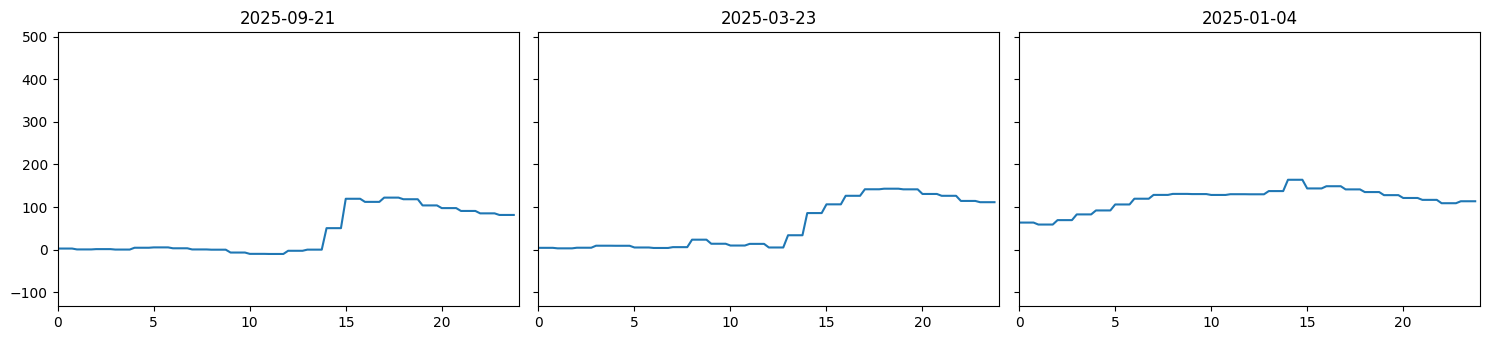

In [44]:
plot_days(price_df, easy)

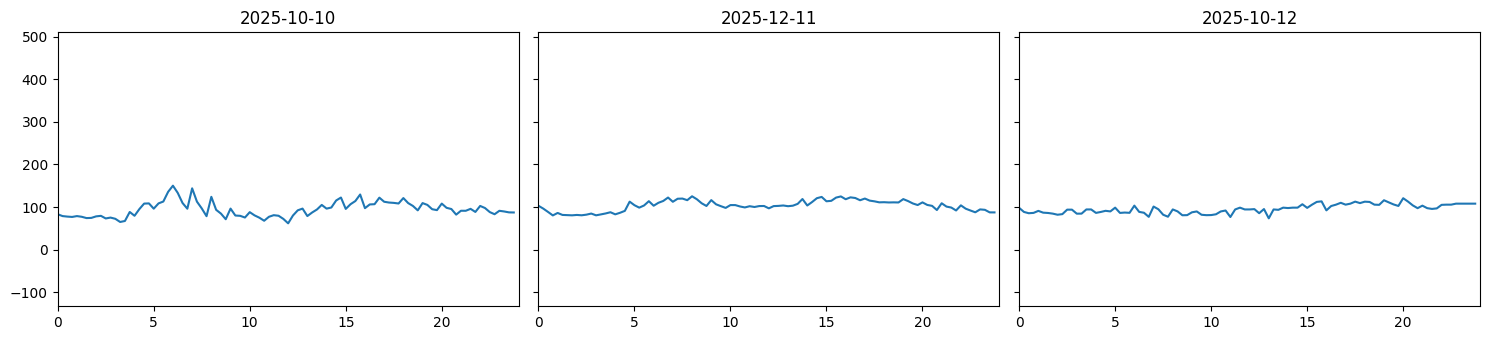

In [ ]:
plot_days(price_df, hard)

In [ ]:
# next steps
# - build heuristic algorithm (1 cycle + rules when to buy and when to sell)
# - build simple LP (just revenue optimization)
# - run both on each (or every 10th day) and compute the optimization gain over the heuristic

# AIM: FAIL FAST, OR DEVELOP POC QUICKLY


# LP formulation:

# indices: 
# gen_idx, load_idx, t_idx 
#
# parameters: 
# cap, p, eff (assumed the same), dt, dod_min, dod_max 
#
# constriants: 
# soc_0 = init_value 
# soc_t = soc_{t-1} + dt*eff*load - dt * gen 
# 
# CAP * dod_min <= soc_t <= CAP * dod_max [energy, no dt needed] 
# 
# dt*load <= P 
# dt*gen <= P 
# 
# Objective: 
# obj = sum_t dt*(gen_t * eff - load_t) * price_t


# Parameter values for first test:
# cap = 2.0      # MWh
# P   = 1.0      # MW
# dt  = 0.25     # hours
# eff = 0.95     # one-way efficiency
# dod_min = 0.10
# dod_max = 0.90
# init_value = 1.0   # MWh

In [48]:
import numpy as np
from scipy.optimize import linprog


def solve_battery_lp(prices, cap=2.0, P=1.0, eff=0.95,
                     dt=0.25, dod_min=0.1, dod_max=0.9,
                     init_soc=None):

    prices = np.array(prices)
    T = len(prices)

    if init_soc is None:
        init_soc = 0.5 * cap

    n_vars = 3 * T

    # Index helpers
    load = lambda t: t
    gen  = lambda t: T + t
    soc  = lambda t: 2*T + t

    # -------------------------
    # Objective (maximize → minimize negative)
    # -------------------------
    c = np.zeros(n_vars)

    for t in range(T):
        c[load(t)] =  dt * prices[t]           # cost
        c[gen(t)]  = -dt * prices[t] * eff    # revenue

    # -------------------------
    # Bounds
    # -------------------------
    bounds = []

    # load bounds
    for t in range(T):
        bounds.append((0, P))

    # gen bounds
    for t in range(T):
        bounds.append((0, P))

    # soc bounds
    soc_min = cap * dod_min
    soc_max = cap * dod_max

    for t in range(T):
        bounds.append((soc_min, soc_max))

    # -------------------------
    # Equality constraints
    # -------------------------
    A_eq = []
    b_eq = []

    # SOC dynamics
    for t in range(T):
        row = np.zeros(n_vars)

        # soc_t
        row[soc(t)] = 1

        if t == 0:
            # soc_0 = init_soc handled separately
            pass
        else:
            row[soc(t-1)] = -1

        row[load(t)] = -dt * eff
        row[gen(t)]  =  dt

        A_eq.append(row)

        if t == 0:
            b_eq.append(init_soc)
        else:
            b_eq.append(0)

    # Optional: force terminal SOC = init_soc
    # (comment out if using rolling horizon)
    row = np.zeros(n_vars)
    row[soc(T-1)] = 1
    A_eq.append(row)
    b_eq.append(init_soc)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # -------------------------
    # Solve
    # -------------------------
    res = linprog(
        c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not res.success:
        raise RuntimeError(res.message)

    return res

In [58]:
def run_opt_for_day(prices: pd.DataFrame, day: pd.Timestamp,
                    cap=2.0, P=1.0, eff=0.95,
                    dt=0.25, dod_min=0.1, dod_max=0.9):

    mask = prices.index.normalize() == day
    day_prices = prices.loc[mask, "price"].values

    res = solve_battery_lp(day_prices, cap=cap, P=P, eff=eff,
                           dt=dt, dod_min=dod_min, dod_max=dod_max)

    T = len(day_prices)

    load = res.x[:T]
    gen  = res.x[T:2*T]
    soc  = res.x[2*T:]

    revenue = -res.fun
    print("Revenue:", revenue)

    step_revenue = dt * day_prices * (eff * gen - load)
    cumulative_revenue = np.cumsum(step_revenue)

    hours = np.arange(T) * dt

    # =========================
    # Two columns
    # =========================
    fig, (ax1, ax3) = plt.subplots(
        1, 2, figsize=(14, 5)
    )

    # -------------------------
    # LEFT: Price + SOC
    # -------------------------
    line1, = ax1.plot(hours, day_prices, label="Price")
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Price")
    ax1.set_xlim(0, 24)

    ax2 = ax1.twinx()
    line2, = ax2.plot(hours, soc, linestyle="--", label="SOC")
    ax2.set_ylabel("SOC (MWh)")

    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")

    ax1.set_title(f"{day.date()}")

    # -------------------------
    # RIGHT: Cumulative Revenue
    # -------------------------
    ax3.plot(hours, cumulative_revenue, label="Cumulative Revenue")
    ax3.set_xlabel("Hour")
    ax3.set_ylabel("Cumulative Revenue")
    ax3.set_xlim(0, 24)
    ax3.legend()
    ax3.set_title(f"Total Revenue = {revenue:.2f}")

    plt.tight_layout()
    plt.show()

Revenue: 142.8132868421053


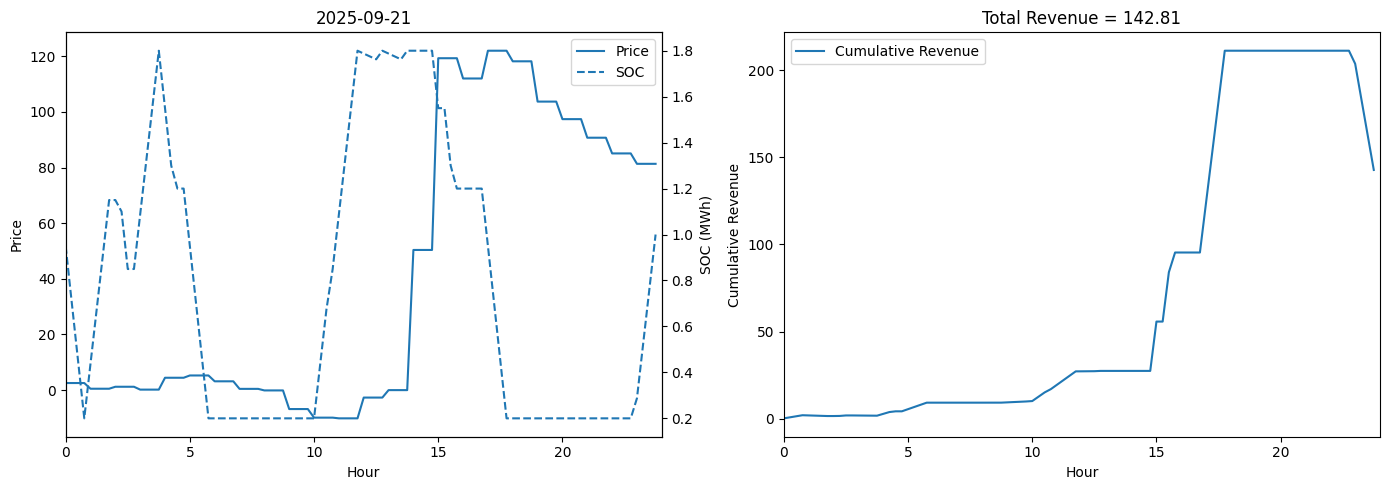

In [59]:
run_opt_for_day(price_df, easy[0])

Revenue: 151.2670634868422


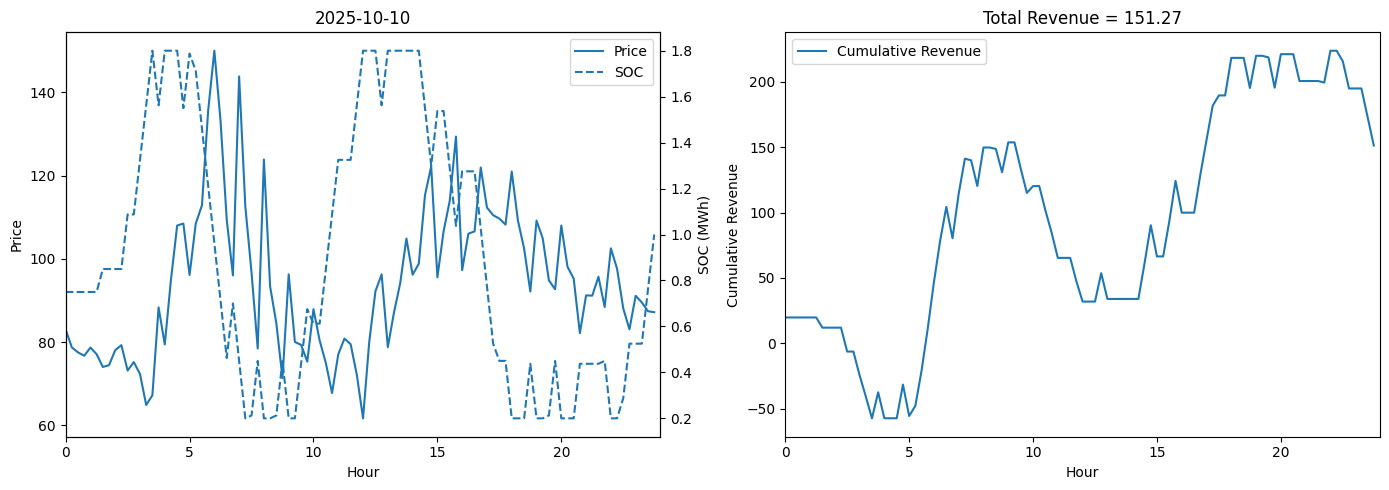

In [60]:
run_opt_for_day(price_df, hard[0])